# Introduction

Welcome to the `PortfolioOptimisers.jl` **user guide** — a fast, skimmable tour of the package.
Each page gives you the *one minimal blessed call* for a task so you can get a portfolio out
the door without reading the source or the reference. It is deliberately shallow: when you want
the full treatment of a topic — every variant, sweep, and trade-off — follow the cross-links
into the [Examples](../examples/00_Examples.md), which are deep single-topic dives.

## The pipeline

`PortfolioOptimisers.jl` is organised as a pipeline. Data flows through a sequence of stages,
and each stage is a swappable estimator:

```text
data ─▶ moments / prior ─▶ optimiser ─▶ constraints & costs ─▶ validation ─▶ post-processing
```

The guide mirrors that spine, one page per stage:

  - [Data and priors](01_Data_and_Priors.md) — turn prices into returns and returns into a
    prior (expected returns, covariance). Deep dives: [moments & priors examples](../examples/2_moments_priors/01_Expected_Returns_Estimation.md).
  - [Optimisers](02_Optimisers.md) — the breadth tour: naive, JuMP (MeanRisk, risk budgeting,
    near-optimal centering), clustering, and meta-optimisers. Deep dives:
    [optimiser examples](../examples/3_optimisers/01_MeanRisk_Objectives.md).
  - [Constraints and costs](03_Constraints_and_Costs.md) — budgets, weight bounds, turnover,
    fees. Deep dives: [constraints & costs examples](../examples/4_constraints_costs/01_Budget_Constraints.md).
  - [Validation and tuning](04_Validation_and_Tuning.md) — cross-validation and hyperparameter
    search. Deep dives: [validation examples](../examples/5_validation_tuning/01_Cross_Validation.md).
  - [Post-processing](05_Post_Processing.md) — discrete allocation and reporting. Deep dives:
    [post-processing examples](../examples/6_post_processing/01_Finite_Allocation.md).
  - [Choosing a strategy](06_Choosing_a_Strategy.md) — a decision framework for picking tools by
    compute budget, rebalance frequency, risk appetite, and capital. Worked end-to-end profiles
    live in [putting it together](../examples/7_putting_it_together/01_Profile_Retail_Daily.md).

## Reading the API

Two conventions run through the whole library. Knowing them up front makes the two-letter
keyword names and the call sites read at a glance.

**Abbreviations follow a scheme.** Composed estimators take their sub-parts as short keyword
arguments. The trailing letter tells you what *kind* of thing the slot holds: `-e` is an
**estimator** (a configuration that still has to be run), `-r` is a **result** (an already-computed
value passed downstream). So `pe` is a prior estimator, but a *computed* prior can be passed into
the same slot; `cle` is a clustering estimator, `clr` a clustering result.

| Abbrev. | Slot | Abbrev. | Slot |
|:--|:--|:--|:--|
| `pe` | prior estimator / result | `slv` | solver(s) |
| `ce` | covariance estimator | `me` | expected-returns (mean) estimator |
| `ve` | variance estimator | `de` | distance estimator |
| `mp` | matrix-processing estimator | `pdm` | posdef-matrix estimator |
| `cle` / `clr` | clustering estimator / result | `re` | regression estimator |
| `wb` | weight bounds | `opt` | optimiser configuration (`JuMPOptimiser` / `HierarchicalOptimiser`) |
| `r` | risk measure | `obj` | objective function |
| `rd` | returns data (`ReturnsResult`) | `fb` | fallback estimator |

**Callable signal: functor vs verb.** Most stages are run with a **verb** applied to an
estimator — `prior(EmpiricalPrior(), rd)`, `optimise(MeanRisk(…))`, `clusterise(…)`,
`factory(…)`. **Risk measures are the exception**: a risk measure is itself a **callable
functor** — you call the measure value directly to evaluate the risk of a portfolio, rather than
passing it to a verb. Rule of thumb: a type that names a *stage* (prior, optimiser, clustering)
is driven by a verb; a type that names a *risk quantity* is called directly.

## The data

Every page in the guide uses the same bundled S&P 500 slice, so the pieces compose. Loading it
and glancing at the prior is the natural first step — `plot_prior` shows the expected
returns, per-asset volatility, and correlation of the data in one view.

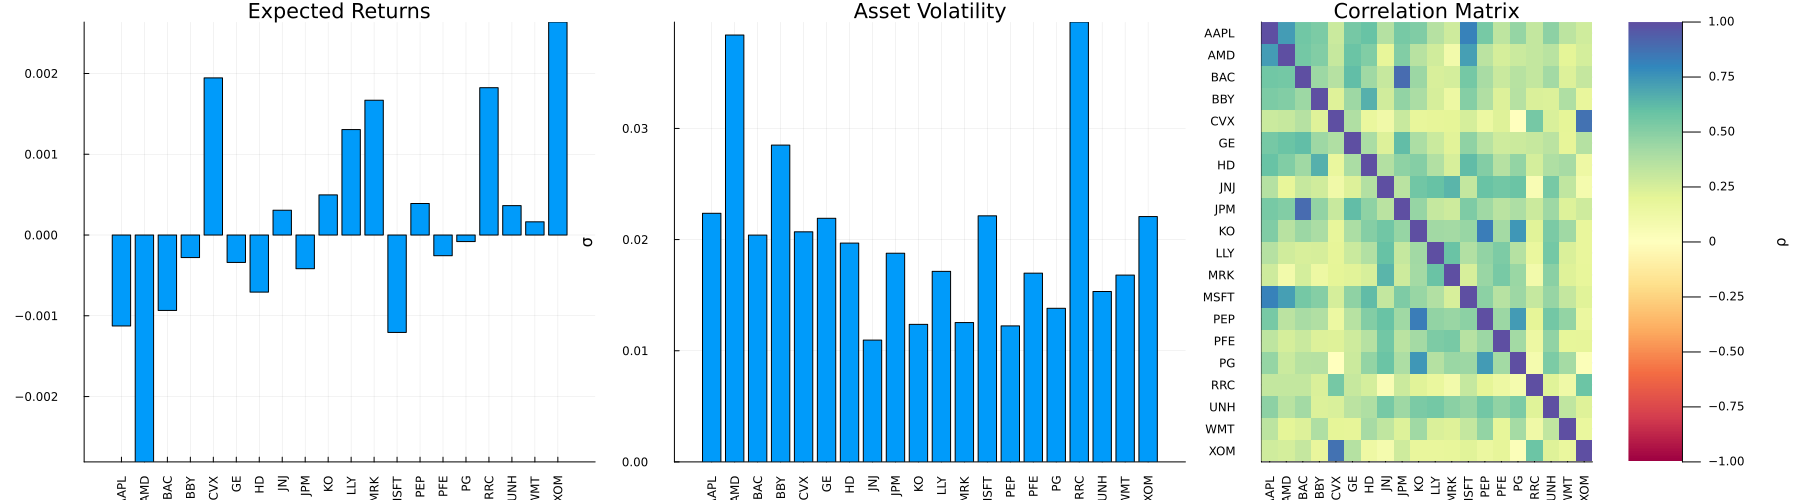

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, StatsPlots, GraphRecipes

X = TimeArray(CSV.File(joinpath(@__DIR__, "../examples/SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

plot_prior(prior(EmpiricalPrior(), rd), rd)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*